**Introduction:**

In the modern maritime industry, the ability to distinguish between rocks and potential underwater mines is crucial for safe navigation. We are
part of a marine research team tasked with developing an Al-based system to classify sonar readings accurately. Our goal is to create a logistic regression model capable of distinguishing between *Rocks* and *Mines* based on sonar data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/UCI_Sonar_Data_augmented_416_rows.csv', header = None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.013100,0.020100,0.004500,0.021700,0.023000,0.048100,0.074200,0.033300,0.136900,0.207900,...,0.016800,0.008600,0.004500,0.006200,0.006500,0.003000,0.006600,0.002900,0.005300,M
1,0.015354,0.018623,0.036787,0.043713,0.056696,0.094884,0.092575,0.159343,0.240738,0.283203,...,0.013898,0.003379,0.006026,0.010617,0.004814,0.002994,0.004773,0.005042,0.003593,M
2,0.031264,0.059338,0.039502,0.064288,0.091723,0.153070,0.136860,0.166467,0.165543,0.162050,...,0.016822,0.011441,0.006343,0.009821,0.009057,0.004907,0.007382,0.005750,0.004989,M
3,0.002500,0.030900,0.017100,0.022800,0.043400,0.122400,0.194700,0.166100,0.136800,0.143000,...,0.014900,0.007700,0.003600,0.011400,0.008500,0.010100,0.001600,0.002800,0.001400,R
4,0.006500,0.012200,0.006800,0.010800,0.021700,0.028400,0.052700,0.057500,0.105400,0.110900,...,0.006900,0.002500,NaN,0.005200,0.003600,0.002600,0.003600,0.000600,0.003500,R


In [2]:
sonar_data = dataset.copy()
feature_names = [
    f'Sonar_Feature_{i:02d}'
    for i in range(1,61)
]
sonar_data.columns = feature_names + ['Target']

sonar_data.head()

,Sonar_Feature_01,Sonar_Feature_02,Sonar_Feature_03,Sonar_Feature_04,Sonar_Feature_05,Sonar_Feature_06,Sonar_Feature_07,Sonar_Feature_08,Sonar_Feature_09,Sonar_Feature_10,...,Sonar_Feature_52,Sonar_Feature_53,Sonar_Feature_54,Sonar_Feature_55,Sonar_Feature_56,Sonar_Feature_57,Sonar_Feature_58,Sonar_Feature_59,Sonar_Feature_60,Target
0,0.013100,0.020100,0.004500,0.021700,0.023000,0.048100,0.074200,0.033300,0.136900,0.207900,...,0.016800,0.008600,0.004500,0.006200,0.006500,0.003000,0.006600,0.002900,0.005300,M
1,0.015354,0.018623,0.036787,0.043713,0.056696,0.094884,0.092575,0.159343,0.240738,0.283203,...,0.013898,0.003379,0.006026,0.010617,0.004814,0.002994,0.004773,0.005042,0.003593,M
2,0.031264,0.059338,0.039502,0.064288,0.091723,0.153070,0.136860,0.166467,0.165543,0.162050,...,0.016822,0.011441,0.006343,0.009821,0.009057,0.004907,0.007382,0.005750,0.004989,M
3,0.002500,0.030900,0.017100,0.022800,0.043400,0.122400,0.194700,0.166100,0.136800,0.143000,...,0.014900,0.007700,0.003600,0.011400,0.008500,0.010100,0.001600,0.002800,0.001400,R
4,0.006500,0.012200,0.006800,0.010800,0.021700,0.028400,0.052700,0.057500,0.105400,0.110900,...,0.006900,0.002500,NaN,0.005200,0.003600,0.002600,0.003600,0.000600,0.003500,R


In [3]:
print("Shape:",sonar_data.shape)

Shape: (416, 61)


In [4]:
sonar_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 61 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sonar_Feature_01  412 non-null    float64
 1   Sonar_Feature_02  411 non-null    float64
 2   Sonar_Feature_03  416 non-null    float64
 3   Sonar_Feature_04  412 non-null    float64
 4   Sonar_Feature_05  416 non-null    float64
 5   Sonar_Feature_06  415 non-null    float64
 6   Sonar_Feature_07  416 non-null    float64
 7   Sonar_Feature_08  416 non-null    float64
 8   Sonar_Feature_09  416 non-null    float64
 9   Sonar_Feature_10  412 non-null    float64
 10  Sonar_Feature_11  410 non-null    float64
 11  Sonar_Feature_12  416 non-null    float64
 12  Sonar_Feature_13  416 non-null    float64
 13  Sonar_Feature_14  414 non-null    float64
 14  Sonar_Feature_15  416 non-null    float64
 15  Sonar_Feature_16  416 non-null    float64
 16  Sonar_Feature_17  416 non-null    float64
 1

In [5]:
sonar_data.describe()

,Sonar_Feature_01,Sonar_Feature_02,Sonar_Feature_03,Sonar_Feature_04,Sonar_Feature_05,Sonar_Feature_06,Sonar_Feature_07,Sonar_Feature_08,Sonar_Feature_09,Sonar_Feature_10,...,Sonar_Feature_51,Sonar_Feature_52,Sonar_Feature_53,Sonar_Feature_54,Sonar_Feature_55,Sonar_Feature_56,Sonar_Feature_57,Sonar_Feature_58,Sonar_Feature_59,Sonar_Feature_60
count,412.000000,411.000000,416.000000,412.000000,416.000000,415.000000,416.000000,416.000000,416.000000,412.000000,...,414.000000,416.000000,416.000000,413.000000,416.000000,416.000000,416.000000,409.000000,416.000000,416.000000
mean,0.029751,0.038325,0.043262,0.053037,0.073757,0.103230,0.120823,0.134825,0.176251,0.206324,...,0.016041,0.013550,0.010887,0.010913,0.009320,0.008017,0.007729,0.007819,0.007903,0.006523
std,0.021341,0.029241,0.033477,0.040191,0.048008,0.051129,0.054976,0.076532,0.105820,0.120629,...,0.011274,0.009042,0.006428,0.006436,0.006338,0.004904,0.005083,0.005733,0.005463,0.004364
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.016100,0.018222,0.021242,0.028899,0.040150,0.068881,0.087219,0.086096,0.105350,0.122484,...,0.008971,0.007800,0.006165,0.006343,0.004900,0.004800,0.004000,0.003900,0.004313,0.003500
50%,0.024696,0.031637,0.035356,0.044238,0.064159,0.096327,0.110536,0.118771,0.155250,0.185461,...,0.014000,0.011700,0.009833,0.009600,0.007640,0.007130,0.006367,0.006171,0.006641,0.005541
75%,0.035102,0.047750,0.055398,0.062795,0.096916,0.126700,0.148520,0.168550,0.224173,0.264654,...,0.020514,0.016700,0.014315,0.013800,0.012002,0.010017,0.010437,0.010100,0.009800,0.008448
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [9]:
# Check missing values

missing_values = sonar_data.isnull().sum()
print('Total null value:',missing_values.sum())
# 2nd sum() is used to total all missing values across the entire DataFrame

print("\nColumns with missing values:")
missing_values[missing_values>0].sort_values(ascending=False)

Total null value: 47

Columns with missing values:


,0
Sonar_Feature_58,7
Sonar_Feature_11,6
Sonar_Feature_47,6
Sonar_Feature_02,5
Sonar_Feature_01,4
Sonar_Feature_04,4
Sonar_Feature_10,4
Sonar_Feature_54,3
Sonar_Feature_18,3
Sonar_Feature_14,2


In [7]:
# Checking missing values in Target Column
print('Total null values in Target Column:',sonar_data['Target'].isnull().sum())

Total null values in Target Column: 0


In [10]:
print('Total duplicate values:',sonar_data.duplicated().sum())

Total duplicate values: 0


In [11]:
# Check value counts of Target Columns
sonar_data['Target'].value_counts()

,count
Target,
M,227
R,189


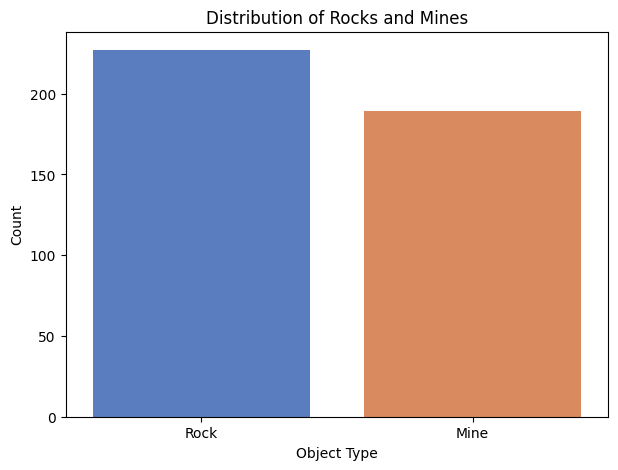

In [12]:
# Target Distribution

plt.figure(figsize=(7,5))
sns.countplot(x = sonar_data['Target'], hue = sonar_data['Target'], palette= 'muted', legend = False)
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.title('Distribution of Rocks and Mines')
plt.xticks([0,1],['Rock', 'Mine'])
plt.show()

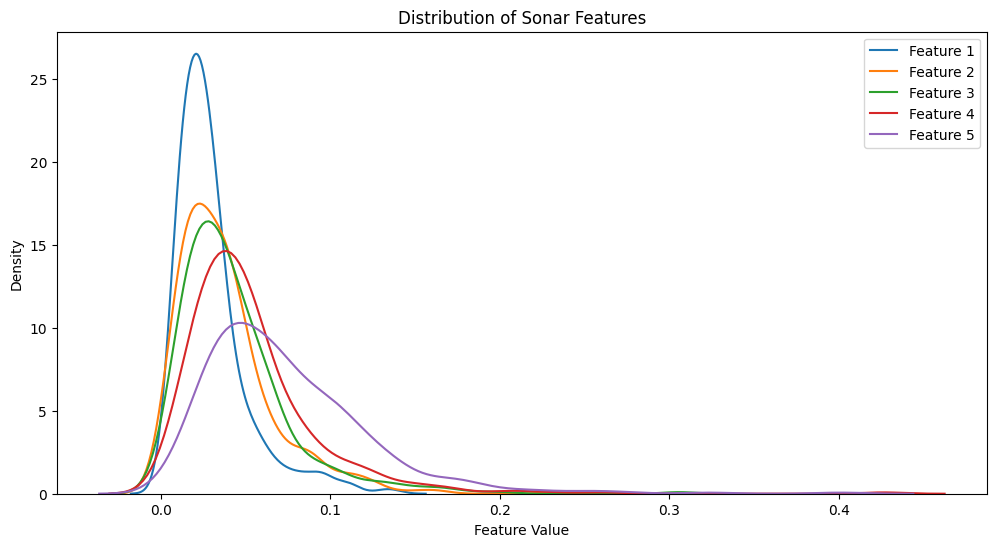

In [13]:
# Feature Distribution (KDE Plot) for Skewness Analysis

# Since there are 60 features, plotting only the first few features

plt.figure(figsize=(12,6))
for i in range(1,6):
  feature = f'Sonar_Feature_{i:02d}'
  sns.kdeplot(
      data = sonar_data,
      x = feature,
      label = f"Feature {i}",
  )

plt.title('Distribution of Sonar Features')
plt.xlabel('Feature Value')
plt.ylabel('Density')
plt.legend()

plt.show()

In [14]:
# Skewness Analysis
# Positive values far from 0 are right skewed, 0 is considered as symmetric distribution

skewness = sonar_data.iloc[:,:-1].skew()

print('Top Positively Skewed Features:')
print(skewness.sort_values(ascending = False).head(10))

print('\nTop Negaively Skewed Features:')
print(skewness.sort_values().head(10))

Top Positively Skewed Features:
Sonar_Feature_04    3.279532
Sonar_Feature_51    2.763811
Sonar_Feature_60    2.579036
Sonar_Feature_03    2.531232
Sonar_Feature_52    2.218792
Sonar_Feature_58    2.029284
Sonar_Feature_05    1.999176
Sonar_Feature_01    1.989033
Sonar_Feature_02    1.949298
Sonar_Feature_56    1.822961
dtype: float64

Top Negaively Skewed Features:
Sonar_Feature_25   -0.703406
Sonar_Feature_26   -0.625658
Sonar_Feature_24   -0.606616
Sonar_Feature_28   -0.580018
Sonar_Feature_27   -0.553501
Sonar_Feature_23   -0.523380
Sonar_Feature_29   -0.378451
Sonar_Feature_22   -0.334260
Sonar_Feature_21   -0.220709
Sonar_Feature_30   -0.106758
dtype: float64


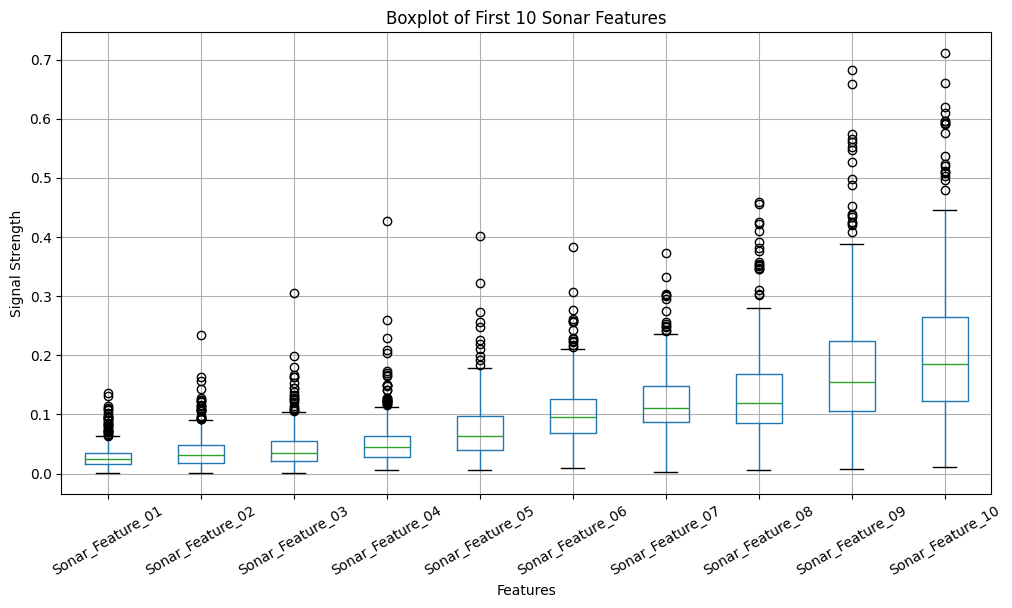

In [15]:
# Feature Distribution (Box Plot) for Outlier Analysis

sonar_data.iloc[:,:10].boxplot(figsize=(12,6))
plt.title('Boxplot of First 10 Sonar Features')
plt.xlabel('Features')
plt.ylabel('Signal Strength')
plt.xticks(rotation = 30)

plt.show()

In [16]:
# Outlier Analysis

Q1 = sonar_data.iloc[:,:-1].quantile(0.25)
Q3 = sonar_data.iloc[:,:-1].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((sonar_data.iloc[:,:-1] < lower_bound) | (sonar_data.iloc[:,:-1] > upper_bound))

outliers_count = outliers.sum()

print('Features with Potential Outliers:')
print(outliers_count[outliers_count>0].sort_values(ascending=False))
# Values which are 0 are not outliers.

Features with Potential Outliers:
Sonar_Feature_01    29
Sonar_Feature_59    28
Sonar_Feature_04    27
Sonar_Feature_46    26
Sonar_Feature_45    25
Sonar_Feature_02    24
Sonar_Feature_52    22
Sonar_Feature_03    21
Sonar_Feature_47    21
Sonar_Feature_50    20
Sonar_Feature_10    19
Sonar_Feature_08    18
Sonar_Feature_09    18
Sonar_Feature_54    18
Sonar_Feature_56    17
Sonar_Feature_55    16
Sonar_Feature_49    16
Sonar_Feature_58    16
Sonar_Feature_44    15
Sonar_Feature_06    14
Sonar_Feature_11    14
Sonar_Feature_48    14
Sonar_Feature_38    13
Sonar_Feature_51    13
Sonar_Feature_07    13
Sonar_Feature_60    12
Sonar_Feature_57    12
Sonar_Feature_42    12
Sonar_Feature_05    11
Sonar_Feature_13    11
Sonar_Feature_14    10
Sonar_Feature_41     9
Sonar_Feature_53     8
Sonar_Feature_43     7
Sonar_Feature_39     7
Sonar_Feature_40     7
Sonar_Feature_12     5
Sonar_Feature_24     4
Sonar_Feature_15     4
Sonar_Feature_28     4
Sonar_Feature_16     3
Sonar_Feature_33     3


In [17]:
# Manually Encoding Target Column

sonar_data['Target'] = sonar_data['Target'].replace({'R': 0, 'M': 1})
print(sonar_data['Target'].value_counts())

Target
1    227
0    189
Name: count, dtype: int64


/tmp/ipykernel_2239/207383729.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sonar_data['Target'] = sonar_data['Target'].replace({'R': 0, 'M': 1})


In [18]:
# Split data into features (x) and target (y)
x = sonar_data.drop(columns='Target', axis = 1)
y = sonar_data['Target']

In [19]:
# Split data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20, random_state=42, stratify = y)
# stratify = y: for training and testing sets to preserve approximately the same class distribution

In [20]:
# Create Logistic Regression Pipeline for Baseline Model

baseline_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Handling Null Values
    ('scaler', StandardScaler()), # Standardization
    ('logistic_regression', LogisticRegression(max_iter = 2000))
])

In [21]:
# Create Logistic Regression Pipeline for Yeo-Johnson Model
# Yeo-Johnson Model handles skewness well

yeo_model = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("power_transform", PowerTransformer(method = 'yeo-johnson')), # skewness aware
    ("logistic_regression", LogisticRegression(max_iter = 2000))
])

In [22]:
# Create Logistic Regression Pipeline for Robust Scaler Model
# Robust Scaler handles outliers well

robust_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()), # outlier robust
    ('logistic_regression', LogisticRegression(max_iter=2000))
])

In [23]:
# Model Selection using Cross-Validation Technique

# Reason for using x_train and y_train instead of x and y:
# Taking only training data and spliting it into 5 parts. Training on 4 parts and validating on the remaining part

baseline_score = cross_val_score(
    baseline_model,
    x_train,
    y_train,
    cv = 5,
    scoring = 'f1'
)

yeo_score = cross_val_score(
    yeo_model,
    x_train,
    y_train,
    cv = 5,
    scoring = 'f1'
)

robust_score = cross_val_score(
    robust_model,
    x_train,
    y_train,
    cv=5,
    scoring = 'f1'
)

print(f"Baseline Model's Mean F1 Score: {baseline_score.mean() * 100:.2f}%")
print(f"Yeo Model's Mean F1 Score: {yeo_score.mean() * 100:.2f}%")
print(f"Robust Model's Mean F1 Score: {robust_score.mean() * 100:.2f}%")

Baseline Model's Mean F1 Score: 91.31%
Yeo Model's Mean F1 Score: 91.90%
Robust Model's Mean F1 Score: 91.22%


In [24]:
# PCA + Yeo Johnson Pipeline
# PCA for dimensionality reduction without loosing significant information, here I am retaining 95% of the variance

yeo_pca_model = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('power_transform', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('logistic_regression', LogisticRegression(max_iter=2000))
])

In [25]:
# Cross Validation after applying PCA with Yeo-Johnson Model

yeo_pca_score = cross_val_score(
    yeo_pca_model,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Yeo-Johnson + PCA's Mean F1 Score: {yeo_pca_score.mean()* 100:.2f}%")

Yeo-Johnson + PCA's Mean F1 Score: 88.96%


In [26]:
# Fitting the pipeline to find the number of PCA components

yeo_pca_model.fit(x_train, y_train)

# named_steps allows us to access an individual step using its name.
pca_model = yeo_pca_model.named_steps['pca']

print("Original number of features:", x_train.shape[1])
print("Number of PCA components:", pca_model.n_components_)

# explained_variance_ratio_ tells how much variance each PCA component contributes.
print(f'\nExplained variance ratio:\n{pca_model.explained_variance_ratio_}')

Original number of features: 60
Number of PCA components: 31

Explained variance ratio:
[0.20841384 0.18599306 0.09272654 0.05116386 0.04703576 0.03784669
 0.03044129 0.02763844 0.02381557 0.02228034 0.01976877 0.01810347
 0.01752359 0.01516042 0.0144699  0.01316624 0.0123888  0.01160143
 0.01131226 0.00993052 0.00955673 0.00884988 0.00820202 0.00805872
 0.0074791  0.00738996 0.00686272 0.00669195 0.00624757 0.00560622
 0.00508486]


In [27]:
# Hyperparameter tuning

param_grid = {
    'logistic_regression__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator = yeo_pca_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)

# Train the model
grid_search.fit(x_train, y_train)

print(f'Best Parameter: {grid_search.best_params_}')
print(f'\nBest Cross-Validation F1 Score: {grid_search.best_score_ * 100:.2f}%')

Best Parameter: {'logistic_regression__C': 1}

Best Cross-Validation F1 Score: 88.96%


In [28]:
# Best model

best_model = grid_search.best_estimator_

In [30]:
# Evaluation on Training Data first to understand how well the model has learned.

# Make Predictions on training data
train_data_prediction = best_model.predict(x_train)

# Evaluate the model on training data
accuracy_train = accuracy_score(y_train, train_data_prediction)
precision_train = precision_score(y_train, train_data_prediction, average = 'binary')
recall_train = recall_score(y_train, train_data_prediction, average = 'binary')
f1_score_train = f1_score(y_train, train_data_prediction, average = 'binary')

print('------------- Performance on Training Data -------------\n')
print(f"Accuracy: {accuracy_train * 100:.2f}%")
print(f"Precision: {precision_train * 100:.2f}%")
print(f"Recall: {recall_train * 100:.2f}%")
print(f"F1 Score: {f1_score_train * 100:.2f}%")

------------- Performance on Training Data -------------

Accuracy: 92.17%
Precision: 91.44%
Recall: 94.48%
F1 Score: 92.93%


In [31]:
# Make Predictions on testing data
test_data_prediction = best_model.predict(x_test)

# Evaluate the model on training data
accuracy_test = accuracy_score(y_test, test_data_prediction)
precision_test = precision_score(y_test, test_data_prediction, average = 'binary')
recall_test = recall_score(y_test, test_data_prediction, average = 'binary')
f1_score_test = f1_score(y_test, test_data_prediction, average = 'binary')

print('------------- Final Test Set Performance -------------\n')
print(f"Accuracy: {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall: {recall_test * 100:.2f}%")
print(f"F1 Score: {f1_score_test * 100:.2f}%")

------------- Final Test Set Performance -------------

Accuracy: 85.71%
Precision: 85.42%
Recall: 89.13%
F1 Score: 87.23%


In [32]:
# Compute Confusion Matrix
cm = confusion_matrix(y_test, test_data_prediction)
print('Confusion Matrix:\n',cm)

# 7 Rocks incorrectly classified as Mine
# 5 Mines incorrectly classified as Rock

Confusion Matrix:
 [[31  7]
 [ 5 41]]


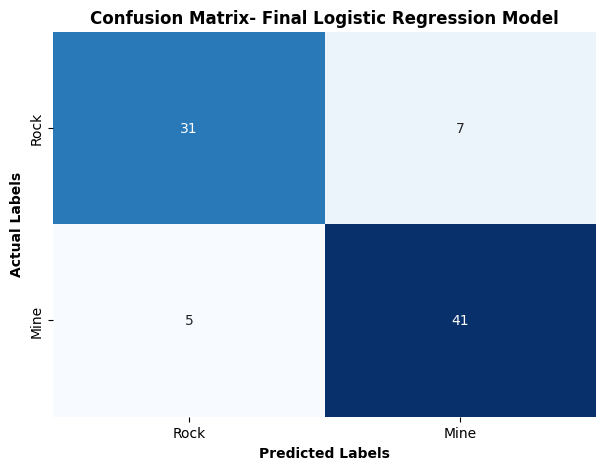

In [33]:
# Plot Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot= True, fmt='d', cmap= 'Blues', cbar=False,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])

# Add labels to the plot
plt.xlabel('Predicted Labels', fontweight='bold')
plt.ylabel('Actual Labels', fontweight='bold')
plt.title('Confusion Matrix- Final Logistic Regression Model', fontweight = 'bold')
plt.show()

In [34]:
# Classification Report
classification_report_test = classification_report(y_test, test_data_prediction, target_names = ['Rock', 'Mine'])
print(classification_report_test)

              precision    recall  f1-score   support

        Rock       0.86      0.82      0.84        38
        Mine       0.85      0.89      0.87        46

    accuracy                           0.86        84
   macro avg       0.86      0.85      0.86        84
weighted avg       0.86      0.86      0.86        84



In [35]:
# ROC-AUC (Receiver Operating Characteristic – Area Under the Curve.)
# It is used mainly for binary classification

y_test_probability = best_model.predict_proba(x_test)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_test_probability,
)

print(f'ROC-AUC Score: {roc_auc * 100:.2f}%')
# There is 85% chance of assigning a higher probability to the Mine sample, which is good.

ROC-AUC Score: 92.85%


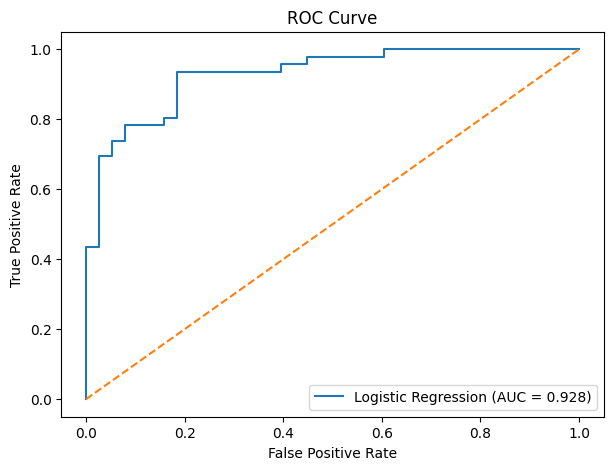

In [36]:
# Plotting ROC-AUC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.show()

In [37]:
# New Sample Prediction

new_sample = pd.DataFrame([[
    0.0200, 0.0371, 0.0428, 0.0207, 0.1954,
    0.0986, 0.4539, 0.1601, 0.3109, 0.2131,
    0.1609, 0.1582, 0.2238, 0.0645, 0.0660,
    0.2273, 0.3100, 0.4997, 0.5078, 0.4797,
    0.5783, 0.5071, 0.4328, 0.9550, 0.0711,
    0.1415, 0.7104, 0.8080, 0.6791, 0.3857,
    0.1307, 0.2604, 0.5125, 0.7547, 0.2537,
    0.8507, 0.6692, 0.3097, 0.4943, 0.2744,
    0.0510, 0.2834, 0.2825, 0.4256, 0.2641,
    0.1386, 0.1051, 0.1343, 0.0383, 0.0324,
    0.0232, 0.0027, 0.0065, 0.0159, 0.0072,
    0.6167, 0.0180, 0.0084, 0.3090, 0.0032
]], columns = x_train.columns)

# Making Predictions
new_pred = best_model.predict(new_sample)

if new_pred[0] == 0:
  print('Prediction: Rock')
else:
  print('Prediction: Mine')

# Prediction Probability
probability = best_model.predict_proba(new_sample)

print(f"Probability of Rock: {probability[0][0] * 100:.2f}%")
print(f"Probability of Mine: {probability[0][1] * 100:.2f}%")

Prediction: Mine
Probability of Rock: 6.76%
Probability of Mine: 93.24%


In [38]:
import joblib

joblib.dump(best_model, 'sonar_final_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [39]:
pip install streamlit joblib pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.2 MB/s eta 0:00:00


In [43]:
%%writefile app.py

Overwriting app.py


In [44]:
! wget -q -O - ipv4.icanhazip.com

136.64.53.187


In [1]:
! streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://two-poets-win.loca.lt
2026-09-06 17:54:36.914 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://136.64.53.187:8502

  Stopping...
^C
